<a href="https://colab.research.google.com/github/anaghasurendran145-maker/mmmm/blob/main/RETAIL_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**E-COMMERCE DATASET ANALYSIS**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/OnlineRetail.csv.zip",encoding='latin1')

*BASIC STATISTICS*

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df=df.dropna()

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])

In [ ]:
df["Revenue"]=df['Quantity']*df['UnitPrice']

In [ ]:
df["Revenue"]

,Revenue
0,15.30
1,20.34
2,22.00
3,20.34
4,20.34
...,...
541904,10.20
541905,12.60
541906,16.60
541907,16.60


*GROUP AND ANALYZE*

In [ ]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

In [ ]:
top_products

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,132567.70
WHITE HANGING HEART T-LIGHT HOLDER,93767.80
JUMBO BAG RED RETROSPOT,83056.52
PARTY BUNTING,67628.43
POSTAGE,66710.24
ASSORTED COLOUR BIRD ORNAMENT,56331.91
RABBIT NIGHT LIGHT,51042.84
CHILLI LIGHTS,45915.41
PAPER CHAIN KIT 50'S CHRISTMAS,41423.78


In [ ]:
country_wise=df.groupby('Country')["Revenue"].sum().sort_values(ascending=False).head(10)

In [ ]:
country_wise

,Revenue
Country,
United Kingdom,6747156.154
Netherlands,284661.540
EIRE,250001.780
Germany,221509.470
France,196626.050
Australia,137009.770
Switzerland,55739.400
Spain,54756.030
Belgium,40910.960


In [ ]:
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

In [ ]:
monthly_revenue=df.groupby('MonthYear')['Revenue'].sum()

In [ ]:
monthly_revenue

,Revenue
MonthYear,
2010-12,552372.860
2011-01,473731.900
2011-02,435534.070
2011-03,578576.210
2011-04,425222.671
2011-05,647011.670
2011-06,606862.520
2011-07,573112.321
2011-08,615078.090


*VISUALIZATIONS*

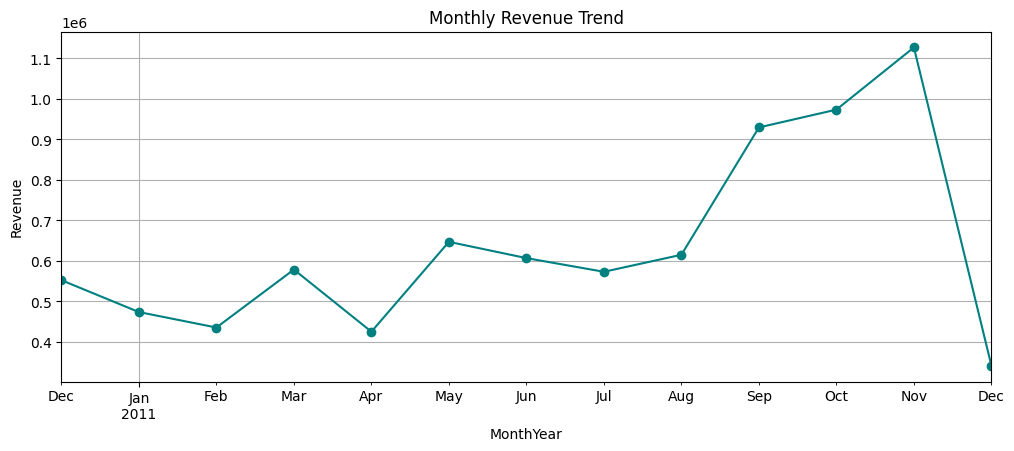

In [ ]:
plt.figure(figsize=(12, 10))
plt.subplot(2, 1, 1)
monthly_revenue.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.grid(True)

/tmp/ipykernel_198/522561250.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_wise.values, y=country_wise.index, palette='viridis')


Text(0.5, 0, 'Total Revenue')

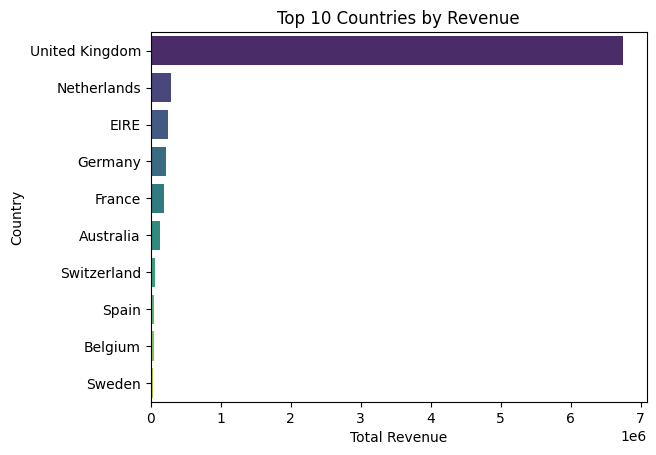

In [ ]:

sns.barplot(x=country_wise.values, y=country_wise.index, palette='viridis')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue')

/tmp/ipykernel_198/1105156010.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='magma')


Text(0, 0.5, 'Product Description')

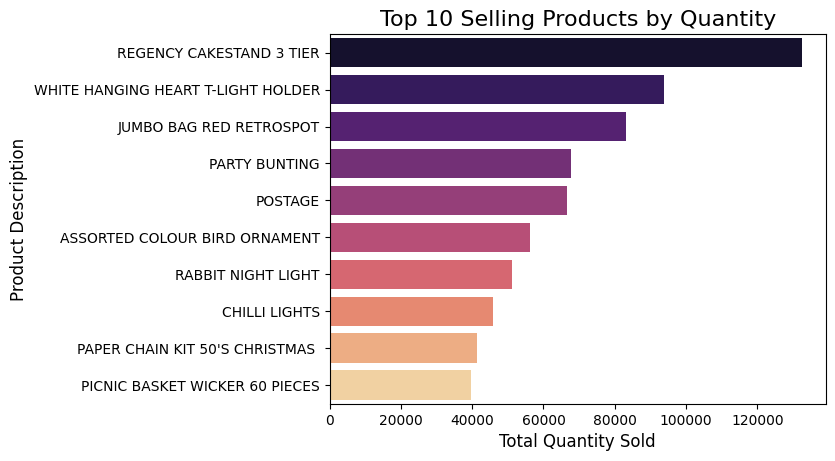

In [ ]:
sns.barplot(x=top_products.values, y=top_products.index, palette='magma')
plt.title('Top 10 Selling Products by Quantity', fontsize=16)
plt.xlabel('Total Quantity Sold', fontsize=12)
plt.ylabel('Product Description', fontsize=12)

**INSIGHTS**

1.**Top 10 selling Products**

.The Regency Cakestand 3 Tier is the clear leader, moving over 130,000 units.

.The top list includes a mix of lighting (Rabbit Night Light, Chilli Lights), party supplies (Party Bunting), and holiday items (Paper Chain Kit 50's Christmas).

2.**Top 10 Countries**

.United Kingdom generate large revenue compared to all countries.

.The Netherlands, EIRE (Ireland), and Germany follow, but their combined revenue is only a fraction of the UK's.

3.**Monthly Revenue Trend**

.There is a revenue surge starting from September and reaching its optimum in November.

.The revenue drops sharply in December.